# Importing Required Libraries:

In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import sys

root_dir = Path.cwd().parent

if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

from src.logger import logger

# Defining Dataset Paths:

In [2]:
TRAIN_DIR = Path("../data/train")
TEST_DIR = Path("../data/test")

print(f"Train directory: {TRAIN_DIR}")
print(f"Test directory: {TEST_DIR}")

logger.info(f"Data paths initialized.")

Train directory: ..\data\train
Test directory: ..\data\test


# Checking Classes:

In [3]:
classes = sorted([f.name for f in TRAIN_DIR.iterdir() if f.is_dir()])

print(f"Classes: {classes}")

logger.info(f"Classes found: {classes}")

Classes: ['cats', 'dogs']


# Count Images:

In [4]:
train_counts = {}

for class_name in classes:
    train_counts[class_name] = len(list((TRAIN_DIR / class_name).glob("*")))

print(f"Train counts: {train_counts}")

Train counts: {'cats': 10000, 'dogs': 10000}


# Count Test Images:

In [5]:
test_counts = {}

for class_name in classes:
    test_counts[class_name] = len(list((TEST_DIR / class_name).glob("*")))

print(f"Test counts: {test_counts}")

Test counts: {'cats': 2500, 'dogs': 2500}


# Plot Distribution:

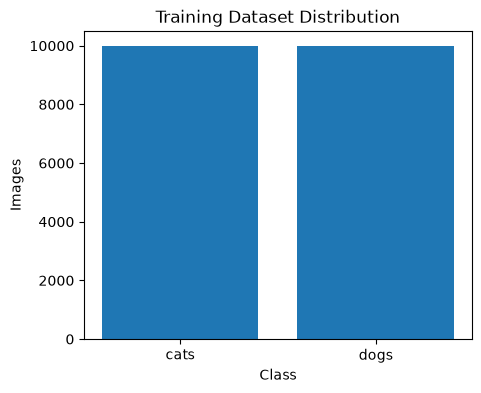

In [6]:
plt.figure(figsize=(5,4))

plt.bar(train_counts.keys(), train_counts.values()) # type:ignore

plt.title("Training Dataset Distribution")
plt.xlabel("Class")
plt.ylabel("Images")

plt.show()

## Insight:
Both bars are similar, the dataset is balanced.

# Show Random Images:

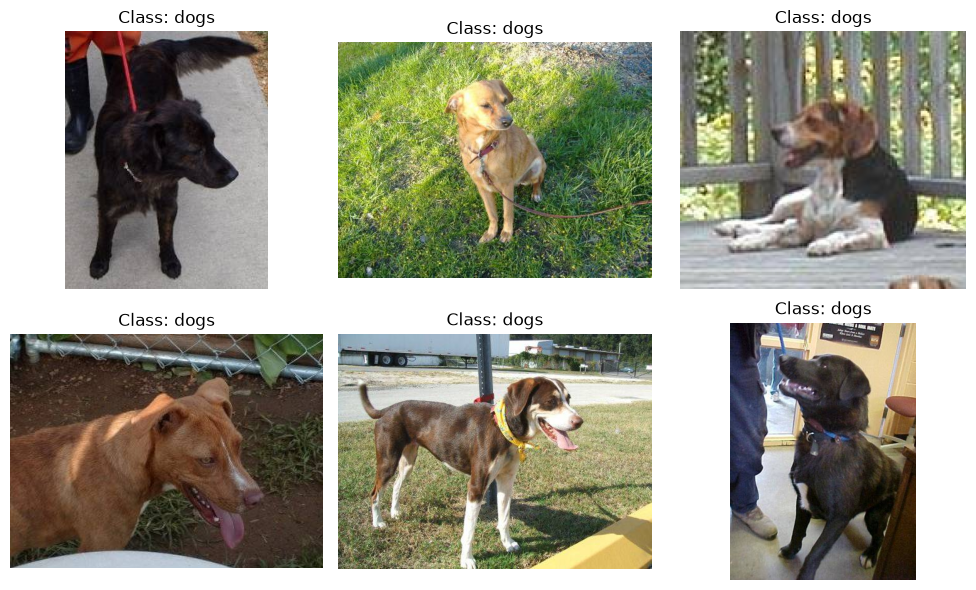

In [7]:
fig, axes = plt.subplots(2,3, figsize=(10, 6))

for axes in axes.flatten():

    cls = random.choice(classes)

    img_path = random.choice(
        list((TRAIN_DIR / cls).glob("*"))
    )

    img = Image.open(img_path)

    axes.imshow(img)
    axes.set_title(f"Class: {cls}")
    axes.axis("off")

plt.tight_layout()
plt.show()

# Image Size:

In [9]:
sizes = []

for cls in classes:
    for img_path in (TRAIN_DIR / cls).glob("*"):
        img = Image.open(img_path)
        sizes.append(img.size)

# Analyze Sizes:

In [10]:
sizes_df = pd.DataFrame(
    sizes,
    columns=["Width", "Height"]
)

In [11]:
sizes_df.head()

,Width,Height
0,500,374
1,300,280
2,403,499
3,150,149
4,499,471


## Check:
We are checking if all images have same dimensions or if resizing will be necessary.

# Checking Image Modes:

In [12]:
modes = {}

for cls in classes:
    for img_path in (TRAIN_DIR / cls).glob("*"):
        img = Image.open(img_path)
        modes[img.mode] = modes.get(img.mode, 0) + 1

print(f"Image modes: {modes}")

Image modes: {'RGB': 20000}


## Insight:
Here we have only *RGB* Images.

If there are grayscale images ('L'), we'll convert everything to RGB during preprocessing.

# Check for Corrupt Images:

In [14]:
corrupt = []

for cls in classes:
    for img_path in (TRAIN_DIR / cls).glob("*"):
        
        try:
            Image.open(img_path).verify()  # Verify that the image is not corrupted
        
        except Exception as e:
            corrupt.append(img_path)

print(f"Corrupted images: {len(corrupt)}")

Corrupted images: 0
